# Playground S6E8 — LightGBM Baseline

Establishes the reference score for the smartphone-addiction task: 5-fold stratified
CV, ROC AUC, out-of-fold predictions, and a `submission.csv`.

Decisions carried over from `01_eda.ipynb`, each backed by a measurement there:

- **Boosted trees.** They beat logistic regression by ~4 AUC points and a small MLP
  by ~2 on this data.
- **No imputation, no NaN indicators.** The NaNs are MCAR (every missingness
  indicator scores AUC 0.50), and LightGBM handles gaps natively.
- **No hand-built interaction features.** They add +0.008 to a linear model but only
  +0.0008 to a tree — the tree finds those interactions on its own.
- **No class weighting.** 71/29 is mild and AUC is rank-based.

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

DATA, TARGET, SEED, N_FOLDS = "data", "addicted_label", 42, 5

train = pd.read_csv(f"{DATA}/train.csv")
test = pd.read_csv(f"{DATA}/test.csv")
train.shape, test.shape

((691369, 14), (296302, 13))

## Features

The three categorical columns are 2–3 levels each. Casting them to pandas `category`
lets LightGBM split on them directly — no one-hot needed. NaN becomes its own
category, which is exactly the desired behaviour.

In [2]:
CAT_COLS = ["gender", "stress_level", "academic_work_impact"]
FEATURES = [c for c in train.columns if c not in ("id", TARGET)]

X = train[FEATURES].copy()
X_test = test[FEATURES].copy()
y = train[TARGET].values

# align categories across train/test so codes mean the same thing in both
for c in CAT_COLS:
    levels = sorted(set(X[c].dropna()) | set(X_test[c].dropna()))
    dtype = pd.CategoricalDtype(categories=levels)
    X[c] = X[c].astype(dtype)
    X_test[c] = X_test[c].astype(dtype)

print(f"{len(FEATURES)} features, {len(CAT_COLS)} categorical")
X.dtypes

12 features, 3 categorical


age                         float64
daily_screen_time_hours     float64
social_media_hours          float64
gaming_hours                float64
work_study_hours            float64
sleep_hours                 float64
notifications_per_day       float64
app_opens_per_day           float64
weekend_screen_time         float64
gender                     category
stress_level               category
academic_work_impact       category
dtype: object

## Cross-validated training

In [3]:
params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    n_estimators=3000,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1,
)

oof = np.zeros(len(X))
test_pred = np.zeros(len(X_test))
scores, best_iters, models = [], [], []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X.iloc[tr_idx], y[tr_idx],
        eval_X=X.iloc[va_idx], eval_y=y[va_idx],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )
    oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
    test_pred += model.predict_proba(X_test)[:, 1] / N_FOLDS

    score = roc_auc_score(y[va_idx], oof[va_idx])
    scores.append(score)
    best_iters.append(model.best_iteration_)
    models.append(model)
    print(f"fold {fold}  AUC {score:.5f}  best_iter {model.best_iteration_}")

print(f"\nmean   {np.mean(scores):.5f} +/- {np.std(scores):.5f}")
print(f"OOF    {roc_auc_score(y, oof):.5f}")

fold 1  AUC 0.96279  best_iter 1934
fold 2  AUC 0.96351  best_iter 1762
fold 3  AUC 0.96389  best_iter 1766
fold 4  AUC 0.96436  best_iter 1733
fold 5  AUC 0.96333  best_iter 1708

mean   0.96358 +/- 0.00053
OOF    0.96357


## Feature importance

Gain, averaged across folds. Worth comparing against the single-feature AUCs in
`01_eda.ipynb` — features that look weak alone can still rank high here, because the
tree uses them in combination.

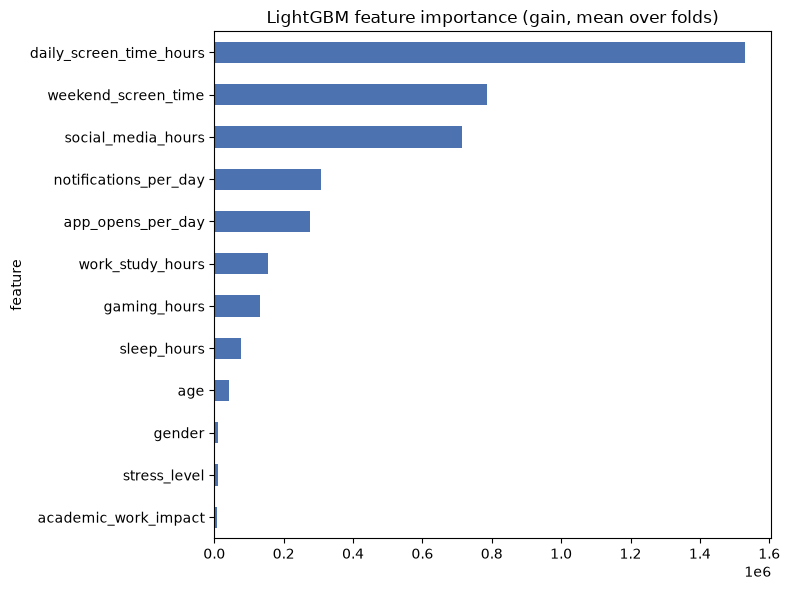

,feature,gain,pct
0,daily_screen_time_hours,1.529564e+06,37.79
1,weekend_screen_time,7.859822e+05,19.42
2,social_media_hours,7.144265e+05,17.65
3,notifications_per_day,3.079945e+05,7.61
4,app_opens_per_day,2.757522e+05,6.81
5,work_study_hours,1.545792e+05,3.82
6,gaming_hours,1.316542e+05,3.25
7,sleep_hours,7.651347e+04,1.89
8,age,4.381393e+04,1.08
9,gender,1.040651e+04,0.26


In [4]:
imp = pd.DataFrame(
    {"feature": FEATURES,
     "gain": np.mean([m.booster_.feature_importance("gain") for m in models], axis=0)}
).sort_values("gain", ascending=False)
imp["pct"] = (imp.gain / imp.gain.sum() * 100).round(2)

ax = imp.set_index("feature")["gain"].iloc[::-1].plot(kind="barh", figsize=(8, 6), color="#4c72b0")
ax.set_title("LightGBM feature importance (gain, mean over folds)")
plt.tight_layout(); plt.show()

imp.reset_index(drop=True)

## Out-of-fold diagnostics

The OOF predictions are the honest read on model behaviour — every row was scored by
a model that never saw it.

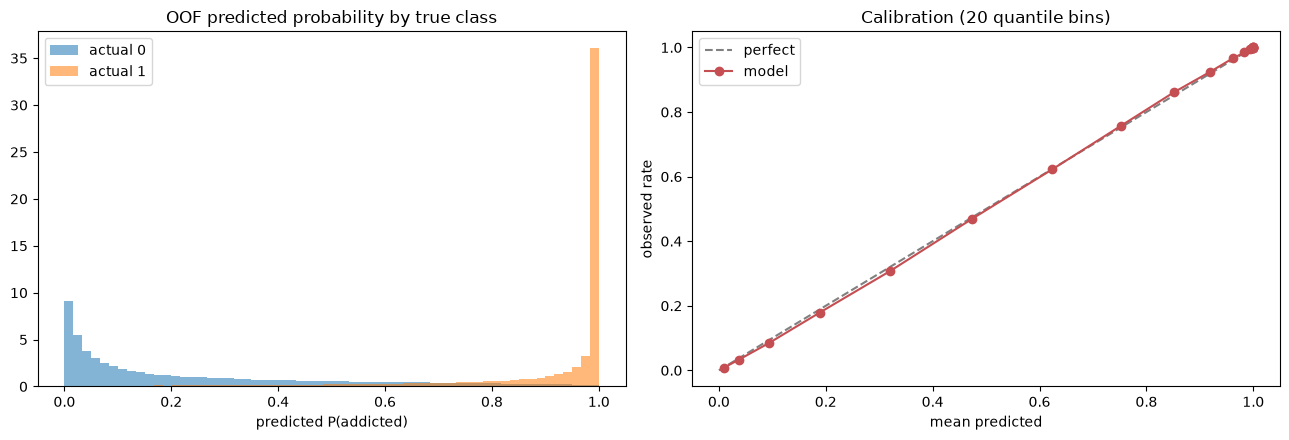

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label in (0, 1):
    axes[0].hist(oof[y == label], bins=60, alpha=.55, density=True, label=f"actual {label}")
axes[0].set_title("OOF predicted probability by true class")
axes[0].set_xlabel("predicted P(addicted)"); axes[0].legend()

# calibration
bins = pd.qcut(oof, 20, duplicates="drop")
cal = pd.DataFrame({"pred": oof, "actual": y}).groupby(bins, observed=True).mean()
axes[1].plot([0, 1], [0, 1], "--", color="grey", label="perfect")
axes[1].plot(cal.pred, cal.actual, "o-", color="#c44e52", label="model")
axes[1].set_title("Calibration (20 quantile bins)")
axes[1].set_xlabel("mean predicted"); axes[1].set_ylabel("observed rate"); axes[1].legend()

plt.tight_layout(); plt.show()

## Submission

The metric is ranking-based, so probabilities go in raw — no thresholding.

In [6]:
submission = pd.DataFrame({"id": test.id, TARGET: test_pred})
submission.to_csv("submission.csv", index=False)

print(submission.shape)
print(submission[TARGET].describe().round(4))
submission.head()

(296302, 2)
count    296302.0000
mean          0.7100
std           0.3675
min           0.0001
25%           0.3924
50%           0.9453
75%           0.9996
max           1.0000
Name: addicted_label, dtype: float64


,id,addicted_label
0,691369,0.999437
1,691370,0.961970
2,691371,0.959218
3,691372,0.988665
4,691373,0.998466


## Where to go next

The single biggest lever from here is **not** more feature engineering — `01_eda.ipynb`
measured that hand-built interactions give a tree +0.0008. In rough order of expected
value:

1. **Tune hyperparameters** (`num_leaves`, `min_child_samples`, `learning_rate`,
   regularisation) with Optuna against this CV setup.
2. **Blend model families.** Train XGBoost and CatBoost on the same folds and average
   the ranks. Decorrelated errors usually buy more than tuning any single model.
3. **More seeds.** Averaging 3–5 seeds of the same config reduces variance cheaply.
4. **Pseudo-labelling** on confident test rows — sometimes worth a little on
   Playground tasks, but verify against CV before trusting it.

Watch fold-to-fold spread when judging any change: differences smaller than the CV
standard deviation are noise, not improvement.